In [1]:
# 1. Imports
import sys
import os
import pandas as pd
from IPython.display import display

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import data_loader, features, econometrics, config

target_volatility = 'Sq_Log_Return'

# macro_shocks = ['CPI_Surprise', 'PPI_Surprise', 'FedFunds_Diff'] # The Inflation & Policy Block
# macro_shocks = ['Unemployment_Surprise', 'Housing_Starts_Surprise'] # The Real Economy Block
macro_shocks = ['Trade_Balance_Surprise', 'M1_Money_Surprise'] # The Global & Liquidity Block
# macro_shocks = ['NFP_Suprise', 'Retail_Sales_Suprise']

raw_data_dict = data_loader.fetch_raw_data()

# Dictionaries to store our multi-sector results
sector_models = {}
sector_stats = {}
sector_var_data = {}

2026-06-22 15:56:26 - src.data_loader - INFO - Configuration matches cache. Loading data from disk...


In [2]:
# 2. Multi-Sector Processing Loop
for etf in config.TARGET_ETFS:
    print(f"\n" + "="*50)
    print(f"PROCESSING SECTOR: {etf}")
    print("="*50)
    
    # Engineer Features
    raw_df = raw_data_dict[etf]
    stat_df = features.engineer_stationary_features(raw_df, etf_name=etf)
    
    # Prepare VAR Data
    var_data = econometrics.prepare_var_data(stat_df, target_vol_col=target_volatility, macro_cols=macro_shocks)
    sector_var_data[etf] = var_data
    
    # Granger Causality
    econometrics.test_granger_causality(var_data, sector_name=etf, max_lag=9)
    
    # Fit VAR Model (Only printing AIC table for the first ETF to save space)
    print(f"\nFitting VAR Model for {etf}...")
    is_first = (etf == config.TARGET_ETFS[0])
    results, optimal_lag = econometrics.fit_var_model(var_data, max_lags=9, verbose=is_first)
    
    sector_models[etf] = results
    
    # Extract Equation Stats
    stats_df = econometrics.get_equation_stats(results, target_vol_col=target_volatility)
    sector_stats[etf] = stats_df


2026-06-22 15:56:26 - src.features - INFO - Engineering features and macro surprises for XLK...
2026-06-22 15:56:26 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLK

--- Granger Causality: Macro -> XLK ---
[Trade_Balance_Surprise]
  Lag 1: p-value = 0.0426 **
  Lag 2: p-value = 0.2843 
  Lag 3: p-value = 0.5691 
  Lag 4: p-value = 0.6897 
  Lag 5: p-value = 0.8466 
  Lag 6: p-value = 0.9107 
  Lag 7: p-value = 0.9500 
  Lag 8: p-value = 0.9770 
  Lag 9: p-value = 0.9891 
[M1_Money_Surprise]
  Lag 1: p-value = 0.5391 
  Lag 2: p-value = 0.8782 
  Lag 3: p-value = 0.9509 
  Lag 4: p-value = 0.9862 
  Lag 5: p-value = 0.9960 
  Lag 6: p-value = 0.9993 
  Lag 7: p-value = 0.9998 
  Lag 8: p-value = 1.0000 
  Lag 9: p-value = 0.9333 

Fitting VAR Model for XLK...


2026-06-22 15:56:28 - src.features - INFO - Engineering features and macro surprises for XLE...
2026-06-22 15:56:28 - src.features - INFO - Calculating Autoregressive Macro Surprises...



LAG SELECTION CRITERIA
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       17.26       17.26   3.129e+07       17.26
1       12.23       12.25   2.055e+05       12.24
2       12.18       12.21   1.957e+05       12.19
3       12.18       12.21   1.945e+05       12.19
4       12.16       12.20   1.915e+05       12.18
5       12.15       12.20   1.893e+05       12.17
6       12.13      12.19*   1.857e+05       12.15
7       12.13       12.20   1.857e+05       12.16
8       12.12       12.20   1.837e+05      12.15*
9      12.12*       12.21  1.833e+05*       12.15
-------------------------------------------------

PROCESSING SECTOR: XLE

--- Granger Causality: Macro -> XLE ---
[Trade_Balance_Surprise]
  Lag 1: p-value = 0.0097 ***
  Lag 2: p-value = 0.1338 
  Lag 3: p-value = 0.3819 
  Lag 4: p-value = 0.7187 
  Lag 5: p-value = 0.8828 
  Lag 6: p-value = 0.9405 
  Lag 7: p-value = 0.

2026-06-22 15:56:31 - src.features - INFO - Engineering features and macro surprises for XLF...
2026-06-22 15:56:31 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLF

--- Granger Causality: Macro -> XLF ---
[Trade_Balance_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-value = 0.0000 ***
  Lag 3: p-value = 0.0000 ***
  Lag 4: p-value = 0.0009 ***
  Lag 5: p-value = 0.0061 ***
  Lag 6: p-value = 0.0996 *
  Lag 7: p-value = 0.2317 
  Lag 8: p-value = 0.3200 
  Lag 9: p-value = 0.0357 **
[M1_Money_Surprise]
  Lag 1: p-value = 0.0946 *
  Lag 2: p-value = 0.3662 
  Lag 3: p-value = 0.6340 
  Lag 4: p-value = 0.8294 
  Lag 5: p-value = 0.9325 
  Lag 6: p-value = 0.9852 
  Lag 7: p-value = 0.9958 
  Lag 8: p-value = 0.9987 
  Lag 9: p-value = 0.9846 

Fitting VAR Model for XLF...


2026-06-22 15:56:33 - src.features - INFO - Engineering features and macro surprises for XLV...
2026-06-22 15:56:33 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLV

--- Granger Causality: Macro -> XLV ---
[Trade_Balance_Surprise]
  Lag 1: p-value = 0.0041 ***
  Lag 2: p-value = 0.1750 
  Lag 3: p-value = 0.3755 
  Lag 4: p-value = 0.2129 
  Lag 5: p-value = 0.3689 
  Lag 6: p-value = 0.3921 
  Lag 7: p-value = 0.4733 
  Lag 8: p-value = 0.6292 
  Lag 9: p-value = 0.7196 
[M1_Money_Surprise]
  Lag 1: p-value = 0.1930 
  Lag 2: p-value = 0.5330 
  Lag 3: p-value = 0.7735 
  Lag 4: p-value = 0.8877 
  Lag 5: p-value = 0.9512 
  Lag 6: p-value = 0.9756 
  Lag 7: p-value = 0.9913 
  Lag 8: p-value = 0.9975 
  Lag 9: p-value = 0.2653 

Fitting VAR Model for XLV...


In [3]:
# 3. SIDE-BY-SIDE EQUATION COMPARISON
print("\n" + "="*80)
print("MULTI-SECTOR VAR EQUATION COMPARISON")
print("="*80)
# This magical pandas function stitches all the sector tables together side-by-side
combined_stats = pd.concat(sector_stats.values(), axis=1, keys=sector_stats.keys())
display(combined_stats.fillna('-'))


MULTI-SECTOR VAR EQUATION COMPARISON


XLK                  XLE                  XLF  \
                             Coef   P-Val  Sig    Coef   P-Val  Sig    Coef   
const                      0.0001  0.0000  ***  0.0001  0.0000  ***  0.0001   
L1.Trade_Balance_Surprise  0.0000  0.7055      -0.0000  0.8493       0.0000   
L1.M1_Money_Surprise       0.0000  0.9601       0.0000  0.7015       0.0000   
L1.Sq_Log_Return           0.1391  0.0000  *** -0.0060  0.6284       0.1372   
L2.Trade_Balance_Surprise  0.0000  0.9616      -0.0000  0.9461       0.0000   
L2.M1_Money_Surprise       0.0000  0.8053      -0.0000  0.9264       0.0000   
L2.Sq_Log_Return           0.1410  0.0000  ***  0.1489  0.0000  ***  0.0932   
L3.Trade_Balance_Surprise  0.0000  0.5575       0.0000  0.3742       0.0000   
L3.M1_Money_Surprise      -0.0000  0.7617       0.0000  0.9960       0.0000   
L3.Sq_Log_Return           0.0225  0.0752    *  0.0956  0.0000  ***  0.0462   
L4.Trade_Balance_Surprise -0.0000  0.2715      -0.0000  0.3266      -0.0000   
L4.M1_Money_Surprise      -0.0000  0.9848       0.0000  0.1924       0.0000   
L4.Sq_Log_Return           0.0728  0.0000  ***  0.1705  0.0000  ***  0.0993   
L5.Trade_Balance_Surprise -0.0000  0.9550       0.0000  0.8722       0.0000   
L5.M1_Money_Surprise       0.0000  0.9293      -0.0000  0.1079      -0.0000   
L5.Sq_Log_Return           0.0802  0.0000  ***  0.1665  0.0000  ***  0.0573   
L6.Trade_Balance_Surprise  0.0000  0.8636      -0.0000  0.9817      -0.0000   
L6.M1_Money_Surprise      -0.0000  0.8839       0.0000  0.7419       0.0000   
L6.Sq_Log_Return           0.0993  0.0000  ***  0.0367  0.0033  ***  0.2031   
L7.Trade_Balance_Surprise  0.0000  0.8499      -0.0000  0.4444      -0.0000   
L7.M1_Money_Surprise       0.0000  0.8484      -0.0000  0.3664      -0.0000   
L7.Sq_Log_Return           0.0060  0.6340       0.1664  0.0000  ***  0.0626   
L8.Trade_Balance_Surprise -0.0000  0.9624       0.0000  0.1965       0.0000   
L8.M1_Money_Surprise       0.0000  0.2095       0.0000  0.0373   **  0.0000   
L8.Sq_Log_Return           0.1031  0.0000  ***  0.0107  0.3896      -0.0003   
L9.Trade_Balance_Surprise  0.0000  0.9342      -0.0000  0.7385      -0.0000   
L9.M1_Money_Surprise      -0.0000  0.0559    * -0.0000  0.0643    * -0.0000   
L9.Sq_Log_Return           0.0427  0.0006  *** -0.0439  0.0004  ***  0.0790   

                                           XLV               
                            P-Val  Sig    Coef   P-Val  Sig  
const                      0.0000  ***  0.0000  0.0000  ***  
L1.Trade_Balance_Surprise  0.8573       0.0000  0.9456       
L1.M1_Money_Surprise       0.9091      -0.0000  0.5527       
L1.Sq_Log_Return           0.0000  ***  0.1343  0.0000  ***  
L2.Trade_Balance_Surprise  0.8872      -0.0000  0.8248       
L2.M1_Money_Surprise       0.8649       0.0000  0.5812       
L2.Sq_Log_Return           0.0000  ***  0.3587  0.0000  ***  
L3.Trade_Balance_Surprise  0.4826       0.0000  0.0867    *  
L3.M1_Money_Surprise       0.9919       0.0000  0.9469       
L3.Sq_Log_Return           0.0002  ***  0.0615  0.0000  ***  
L4.Trade_Balance_Surprise  0.1943      -0.0000  0.1950       
L4.M1_Money_Surprise       0.9656      -0.0000  0.9392       
L4.Sq_Log_Return           0.0000  *** -0.0430  0.0012  ***  
L5.Trade_Balance_Surprise  0.3907      -0.0000  0.3892       
L5.M1_Money_Surprise       0.8008      -0.0000  0.9441       
L5.Sq_Log_Return           0.0000  ***  0.0482  0.0003  ***  
L6.Trade_Balance_Surprise  0.8852       0.0000  0.7669       
L6.M1_Money_Surprise       0.8236       0.0000  0.9411       
L6.Sq_Log_Return           0.0000  ***  0.0188  0.1563       
L7.Trade_Balance_Surprise  0.8224       0.0000  0.5544       
L7.M1_Money_Surprise       0.9116      -0.0000  0.8565       
L7.Sq_Log_Return           0.0000  ***  0.0276  0.0377   **  
L8.Trade_Balance_Surprise  0.0141   **  0.0000  0.9320       
L8.M1_Money_Surprise       0.3524       0.0000  0.0129   **  
L8.Sq_Log_Return           0.9820       0.1055 

In [4]:
to_show = combined_stats[combined_stats.xs("Sig", axis=1, level=1).isin(["*","**","***"]).any(axis=1)]
display(to_show[~to_show.index.astype(str).str.contains("Return")])

XLK                  XLE                  XLF  \
                             Coef   P-Val  Sig    Coef   P-Val  Sig    Coef   
const                      0.0001  0.0000  ***  0.0001  0.0000  ***  0.0001   
L3.Trade_Balance_Surprise  0.0000  0.5575       0.0000  0.3742       0.0000   
L8.Trade_Balance_Surprise -0.0000  0.9624       0.0000  0.1965       0.0000   
L8.M1_Money_Surprise       0.0000  0.2095       0.0000  0.0373   **  0.0000   
L9.Trade_Balance_Surprise  0.0000  0.9342      -0.0000  0.7385      -0.0000   
L9.M1_Money_Surprise      -0.0000  0.0559    * -0.0000  0.0643    * -0.0000   

                                        XLV               
                            P-Val  Sig Coef   P-Val  Sig  
const                      0.0000  ***  0.0  0.0000  ***  
L3.Trade_Balance_Surprise  0.4826       0.0  0.0867    *  
L8.Trade_Balance_Surprise  0.0141   **  0.0  0.9320       
L8.M1_Money_Surprise       0.3524       0.0  0.0129   **  
L9.Trade_Balance_Surprise  0.0018  *** -0.0  0.8296       
L9.M1_Money_Surprise       0.1914      -0.0  0.0009  ***


VISUAL DIAGNOSTICS: XLK


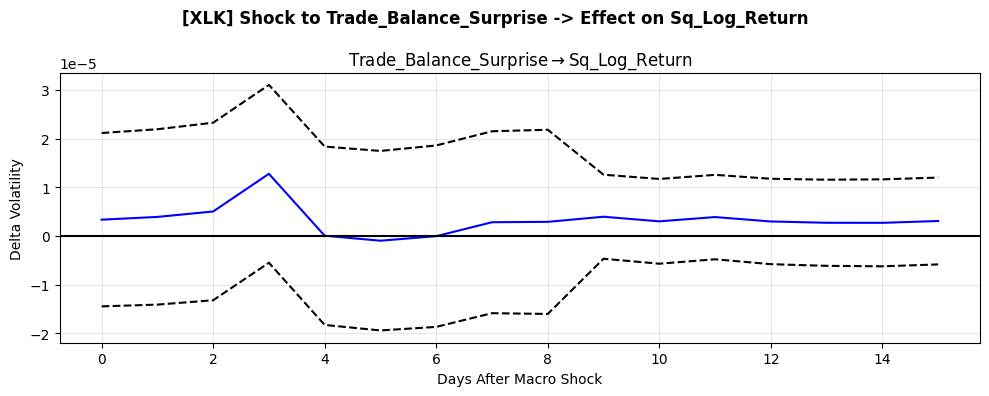

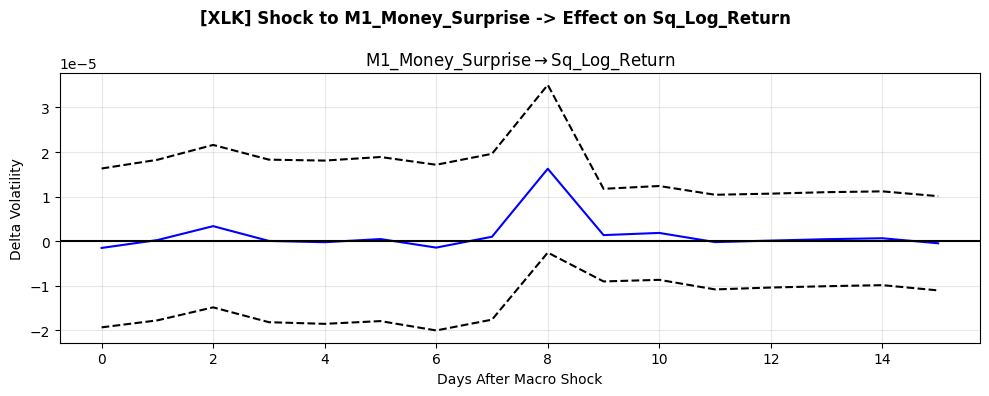

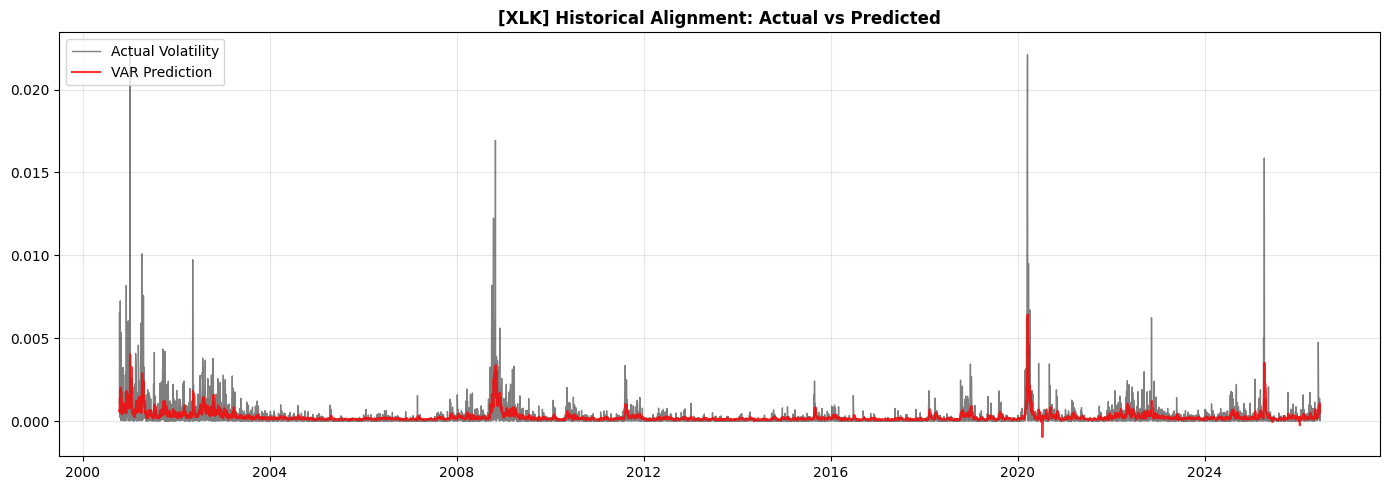


VISUAL DIAGNOSTICS: XLE


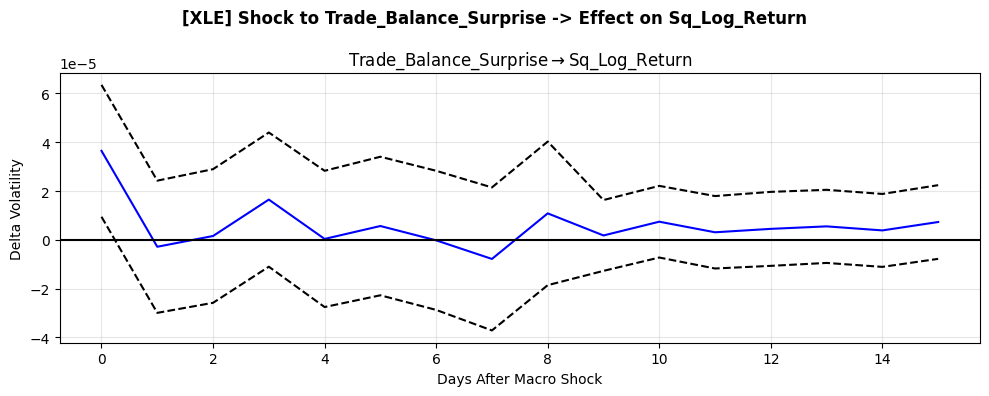

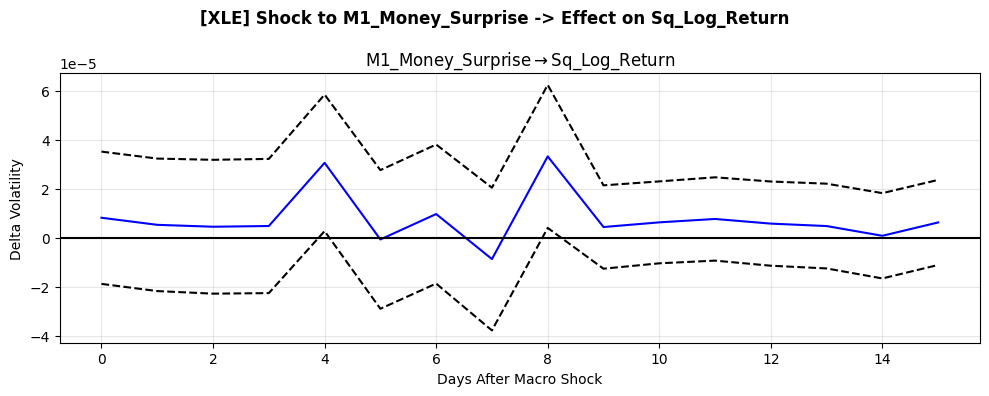

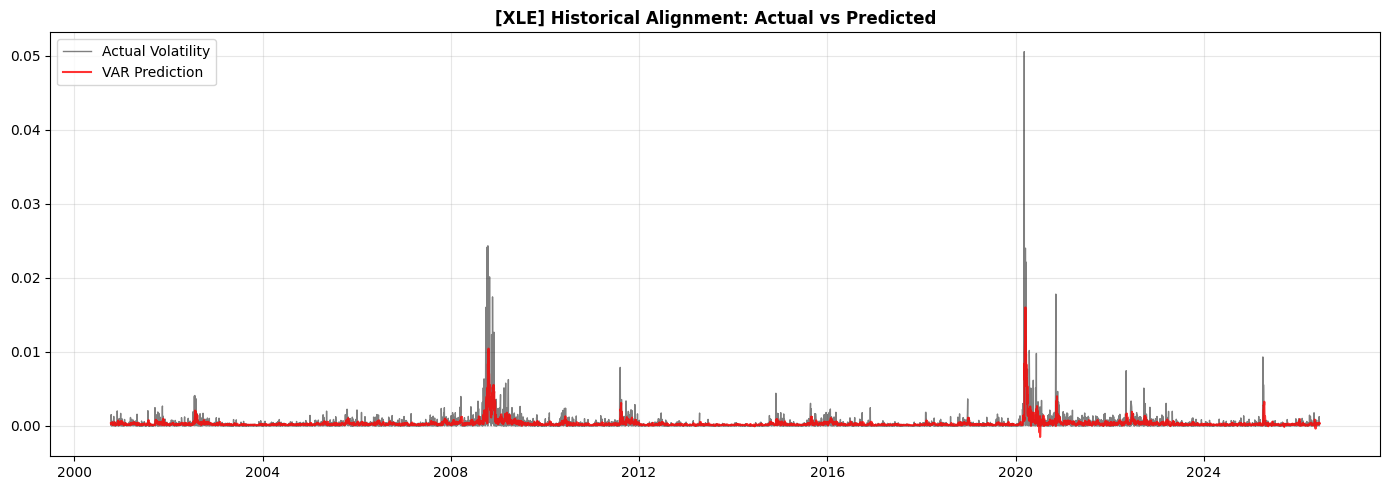


VISUAL DIAGNOSTICS: XLF


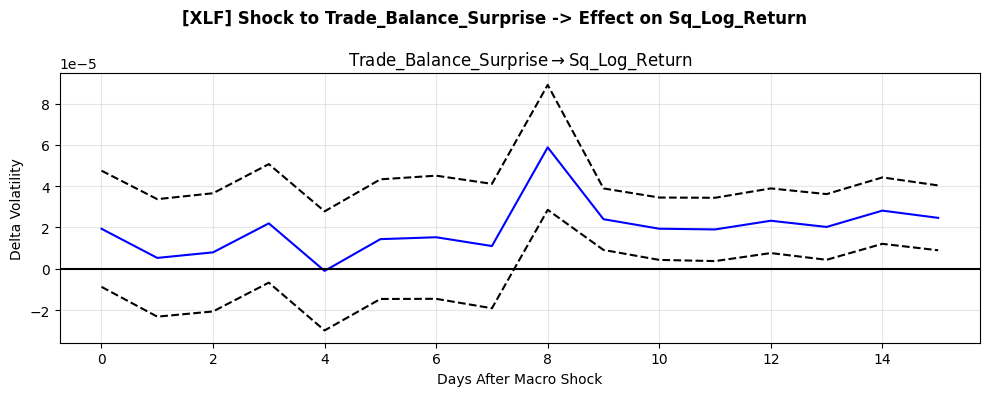

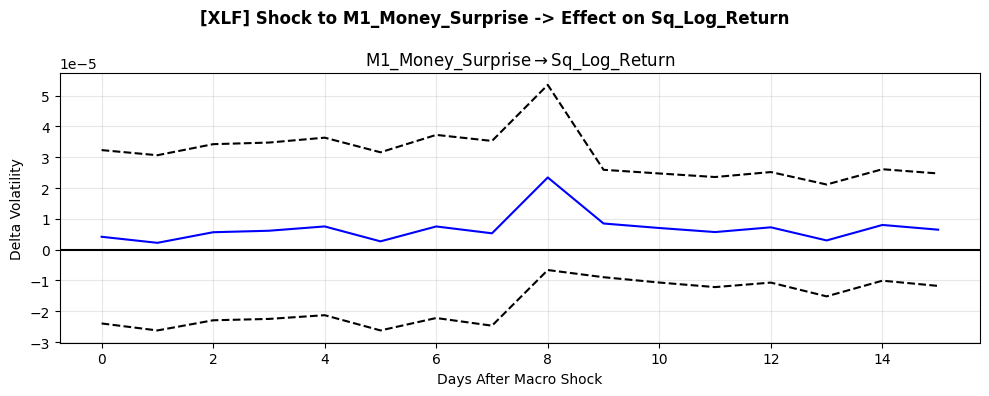

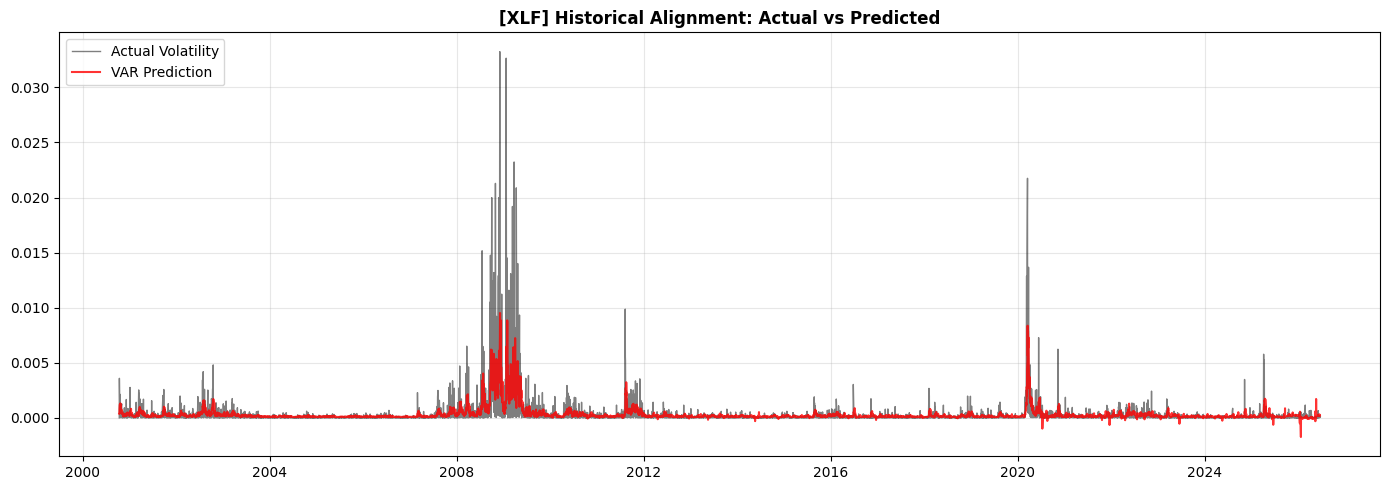


VISUAL DIAGNOSTICS: XLV


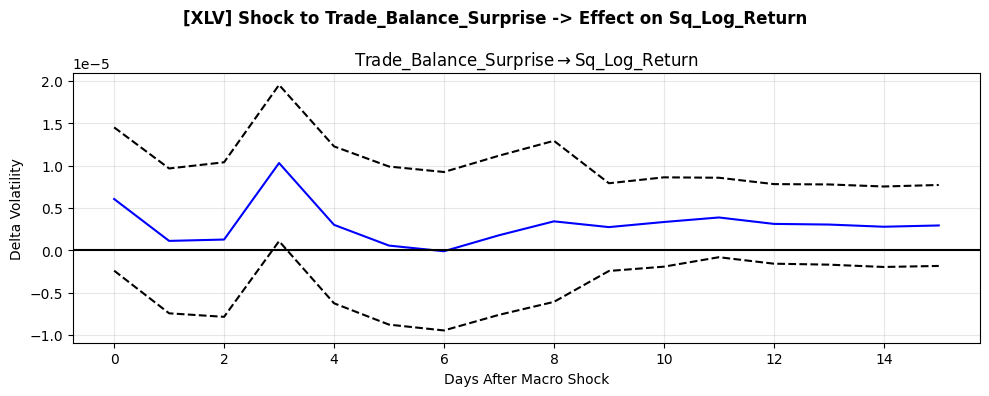

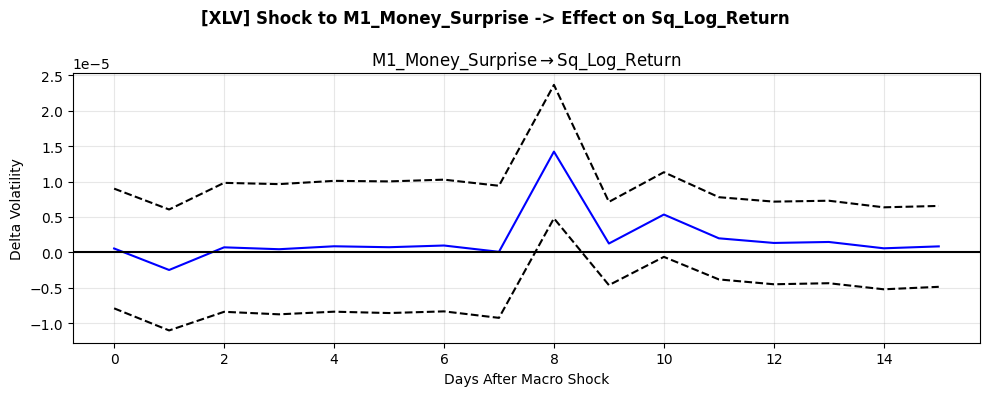

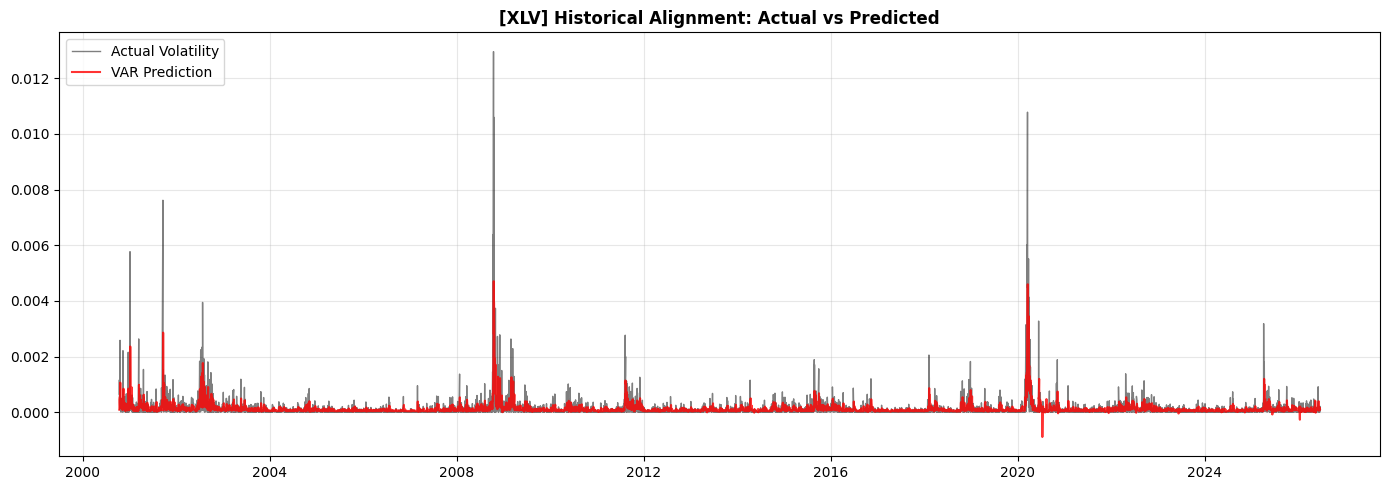

In [5]:
# 4. VISUALIZATIONS
for etf in config.TARGET_ETFS:
    print("\n" + "="*80)
    print(f"VISUAL DIAGNOSTICS: {etf}")
    print("="*80)
    
    results = sector_models[etf]
    var_data = sector_var_data[etf]
    
    econometrics.plot_irfs(results, var_data, sector_name=etf, irf_periods=15)
    econometrics.plot_historical_fit(results, var_data, sector_name=etf)
